# Agenda

Decision Trees - Classification and Regression Trees

Hyperparameters

Feature importance

SMOTE

# Classification trees

<img src="./images/classification_trees_1.png" alt="sample" width="1000"/>

<img src="./images/classification_trees_2.png" alt="sample" width="1000"/>

<img src="./images/classification_trees_3.png" alt="sample" width="1000"/>

<img src="./images/classification_trees_4.png" alt="sample" width="1000"/>

<img src="./images/classification_trees_5.png" alt="sample" width="1000"/>

<img src="./images/classification_trees_6.png" alt="sample" width="1000"/>

<img src="./images/classification_trees_7.png" alt="sample" width="1000"/>

# Regression trees

<img src="./images/regression_trees_1.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_2.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_3.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_4.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_5.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_6.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_7.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_8.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_9.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_10.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_11.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_12.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_13.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_14.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_15.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_16.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_17.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_18.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_19.png" alt="sample" width="1000"/>

<img src="./images/regression_trees_20.png" alt="sample" width="1000"/>

# Code Demo - Decision Tree Classifier

Best params: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}
Test accuracy: 0.94
              precision    recall  f1-score   support

           0      0.934     0.947     0.940        75
           1      0.946     0.933     0.940        75

    accuracy                          0.940       150
   macro avg      0.940     0.940     0.940       150
weighted avg      0.940     0.940     0.940       150



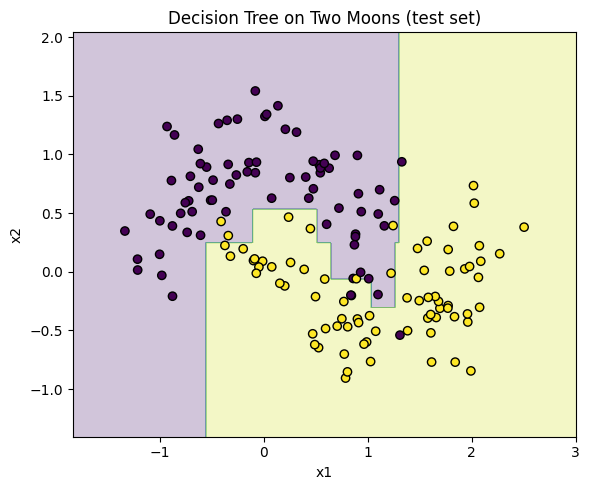

In [17]:
# Decision Tree on a non-linear dataset (two moons)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# 1) Create a non-linear dataset
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) (Optional) Hyperparameter tuning
param_grid = {
    "max_depth": [3, 5, 8, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
tree = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(tree, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print("Best params:", grid.best_params_)

# 4) Evaluate
y_pred = best_tree.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# 5) Visualize decision regions
def plot_decision_boundary(model, X, y, title="Decision boundary"):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

plot_decision_boundary(best_tree, X_test, y_test,
                       title="Decision Tree on Two Moons (test set)")

Dataset shape: (1599, 12)
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
Accuracy: 0.5825

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.12      0.23      0.16        13
           5       0.68      0.69      0.69       170
           6       0.59      0.52      0.55       160
           7       0.47      0.56      0.51        50
           8       0.33      0.20      0.25         5

    accuracy                           0.58       400
   macro avg       0.37      0.37      0.36       400
weighted avg       0.59      0.58      0.59       400



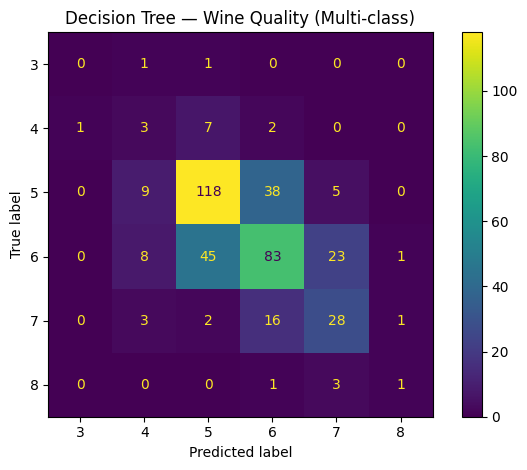

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}

Tuned Model Accuracy: 0.6025

Tuned Model Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.21      0.23      0.22        13
           5       0.69      0.68      0.68       170
           6       0.59      0.62      0.61       160
           7       0.48      0.44      0.46        50
           8       0.50      0.20      0.29         5

    accuracy                           0.60       400
   macro avg       0.41      0.36      0.38       400
weighted avg       0.60      0.60      0.60       400



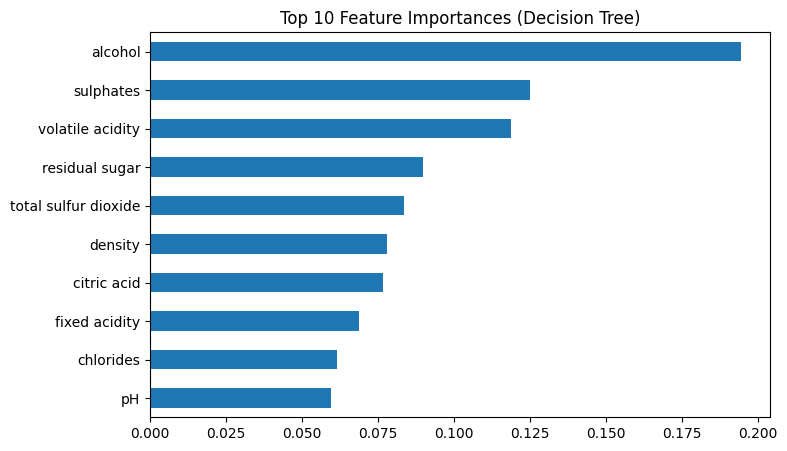

In [19]:
# Decision Tree Classifier on Wine Quality (Multi-class)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

# 1) Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Dataset shape:", df.shape)
print(df['quality'].value_counts().sort_index())

# 2) Split features and target
X = df.drop(columns=['quality'])
y = df['quality']   # Multi-class target: values from 3 to 8

# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4) Define and train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 5) Predictions and evaluation
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
plt.title("Decision Tree — Wine Quality (Multi-class)")
plt.tight_layout()
plt.show()

# 6) (Optional) Hyperparameter tuning
param_grid = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "criterion": ["gini", "entropy"]
}
grid = GridSearchCV(dt, param_grid, scoring="accuracy", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_tree = grid.best_estimator_
y_pred_best = best_tree.predict(X_test)
print("\nTuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nTuned Model Classification Report:\n", classification_report(y_test, y_pred_best))

# 7) Visualize feature importances
importances = best_tree.feature_importances_
features = X.columns
fi = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
fi.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.gca().invert_yaxis()
plt.show()

### Feature importances

When a decision tree grows, it repeatedly splits the data at certain feature thresholds, e.g.:

if alcohol > 10.5 then quality = high
else quality = low

At each split, the tree measures how much “purity” of the target improved.

Each split gives a “reduction in impurity”: The larger the impurity reduction, the more important that feature.

# SMOTE - Synthetic Minority Over-sampling method

Class distribution (overall): Counter({5: 681, 6: 638, 7: 199, 4: 53, 8: 18, 3: 10})
Class distribution (train): Counter({5: 511, 6: 478, 7: 149, 4: 40, 8: 13, 3: 8})
Class distribution (test): Counter({5: 170, 6: 160, 7: 50, 4: 13, 8: 5, 3: 2})


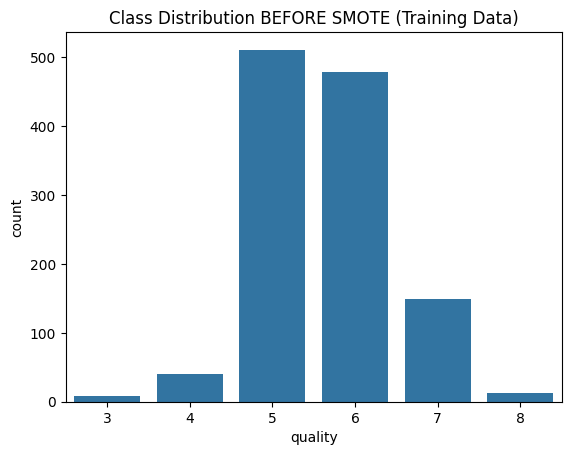


Baseline Accuracy: 0.5825

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.12      0.23      0.16        13
           5       0.68      0.69      0.69       170
           6       0.59      0.52      0.55       160
           7       0.47      0.56      0.51        50
           8       0.33      0.20      0.25         5

    accuracy                           0.58       400
   macro avg       0.37      0.37      0.36       400
weighted avg       0.59      0.58      0.59       400



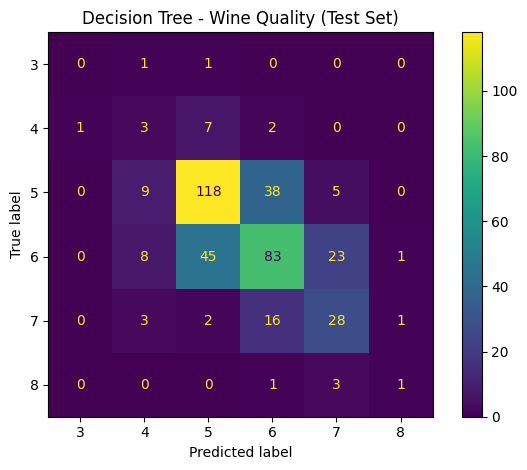

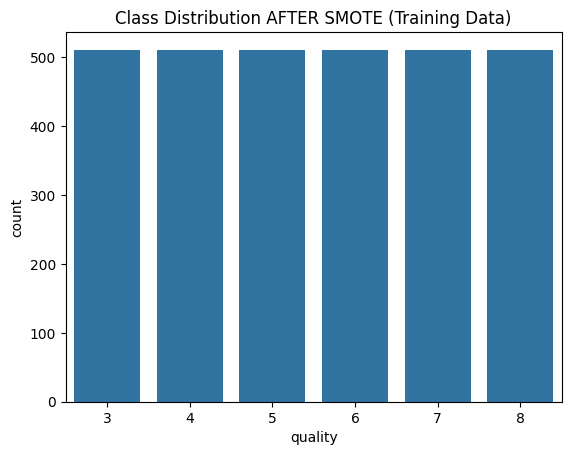


Baseline (SMOTE + DT) Accuracy: 0.56

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.19      0.38      0.26        13
           5       0.68      0.62      0.65       170
           6       0.57      0.55      0.56       160
           7       0.46      0.48      0.47        50
           8       0.10      0.20      0.13         5

    accuracy                           0.56       400
   macro avg       0.33      0.37      0.35       400
weighted avg       0.58      0.56      0.57       400



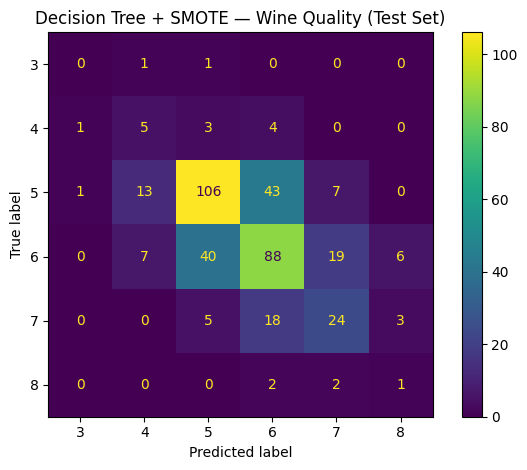


Best Params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 1, 'smote__k_neighbors': 2}

Tuned Model Accuracy: 0.5475

Tuned Model Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.13      0.31      0.18        13
           5       0.71      0.62      0.66       170
           6       0.56      0.53      0.54       160
           7       0.42      0.50      0.46        50
           8       0.11      0.20      0.14         5

    accuracy                           0.55       400
   macro avg       0.32      0.36      0.33       400
weighted avg       0.58      0.55      0.56       400



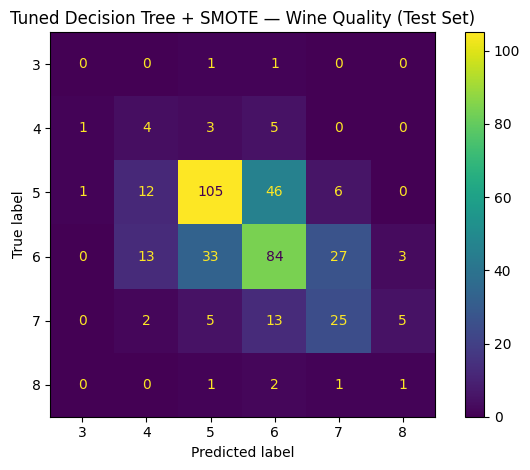


Top Feature Importances:
 alcohol                 0.167535
volatile acidity        0.164336
sulphates               0.160814
total sulfur dioxide    0.124705
chlorides               0.071465
density                 0.063249
free sulfur dioxide     0.060445
residual sugar          0.051991
pH                      0.049853
citric acid             0.048852
dtype: float64


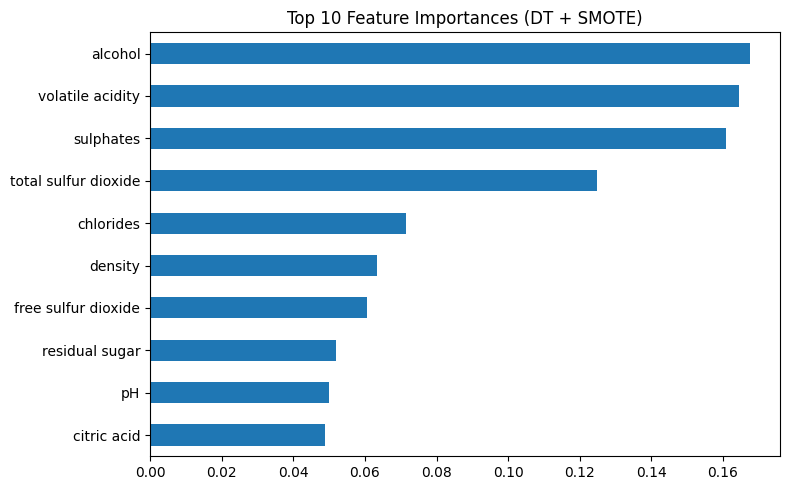

In [20]:
# Decision Tree (Multi-class) on Wine Quality with SMOTE
# - Uses imblearn Pipeline so SMOTE happens only on training data (no leakage)
# - Works with multi-class target (quality scores 3..8)
# - Includes optional hyperparameter tuning

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

########## BEFORE SMOTE ############

# 1) Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

X = df.drop(columns=['quality'])
y = df['quality']  # multi-class labels: typically 3..8

print("Class distribution (overall):", Counter(y))

# 2) Train/test split (stratified preserves class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Class distribution (train):", Counter(y_train))
print("Class distribution (test):", Counter(y_test))

sns.countplot(x=y_train)
plt.title("Class Distribution BEFORE SMOTE (Training Data)")
plt.show()

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("\nBaseline Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Decision Tree - Wine Quality (Test Set)")
plt.tight_layout()
plt.show()

########## AFTER SMOTE ############

sm = SMOTE(k_neighbors=3, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

sns.countplot(x=y_train_res)
plt.title("Class Distribution AFTER SMOTE (Training Data)")
plt.show()

# 3) Pipeline: SMOTE -> Decision Tree
# Use k_neighbors=3 to be safe with very small classes
pipe = ImbPipeline(steps=[
    ('smote', SMOTE(k_neighbors=3, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# 4) Fit baseline pipeline and evaluate
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\nBaseline (SMOTE + DT) Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Decision Tree + SMOTE — Wine Quality (Test Set)")
plt.tight_layout()
plt.show()

########## HYPERPARAMETER TUNING ###############

# 5) (Optional) Hyperparameter tuning WITH SMOTE inside CV (no leakage)
param_grid = {
    'dt__max_depth': [3, 5, 7, 9, None],
    'dt__min_samples_leaf': [1, 3, 5, 10],
    'dt__criterion': ['gini', 'entropy', 'log_loss'],  # sklearn >=1.1
    # You can also tune SMOTE if needed:
    'smote__k_neighbors': [2, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)
best = grid.best_estimator_

y_pred_best = best.predict(X_test)
print("\nTuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nTuned Model Classification Report:\n", classification_report(y_test, y_pred_best))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title("Tuned Decision Tree + SMOTE — Wine Quality (Test Set)")
plt.tight_layout()
plt.show()

# 6) (Optional) Inspect feature importances from the tuned tree
import pandas as pd
fi = pd.Series(best.named_steps['dt'].feature_importances_, index=X.columns)\
       .sort_values(ascending=False)
print("\nTop Feature Importances:\n", fi.head(10))

plt.figure(figsize=(8,5))
fi.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (DT + SMOTE)")
plt.tight_layout()
plt.show()

### How SMOTE works

What SMOTE does - Creates new synthetic samples for minority classes

Why it helps in some models - Those models learn by looking at distances between points

Why it fails for Decision Trees - Trees only care about “yes/no” splits, not how dense a region is

What can happen - The tree gets more noise, makes more splits, and accuracy drops

Better alternative - Use class_weight="balanced"

### Using class_weight of 'balanced'


Decision Tree (Class Weight Balanced):
              precision    recall  f1-score   support

           3      1.000     0.500     0.667         2
           4      0.294     0.385     0.333        13
           5      0.727     0.659     0.691       170
           6      0.563     0.588     0.575       160
           7      0.473     0.520     0.495        50
           8      0.167     0.200     0.182         5

    accuracy                          0.598       400
   macro avg      0.537     0.475     0.491       400
weighted avg      0.610     0.598     0.602       400



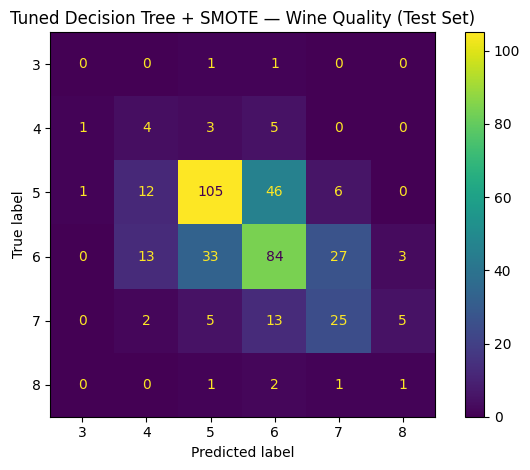


Top Feature Importances:
 alcohol                 0.167535
volatile acidity        0.164336
sulphates               0.160814
total sulfur dioxide    0.124705
chlorides               0.071465
density                 0.063249
free sulfur dioxide     0.060445
residual sugar          0.051991
pH                      0.049853
citric acid             0.048852
dtype: float64


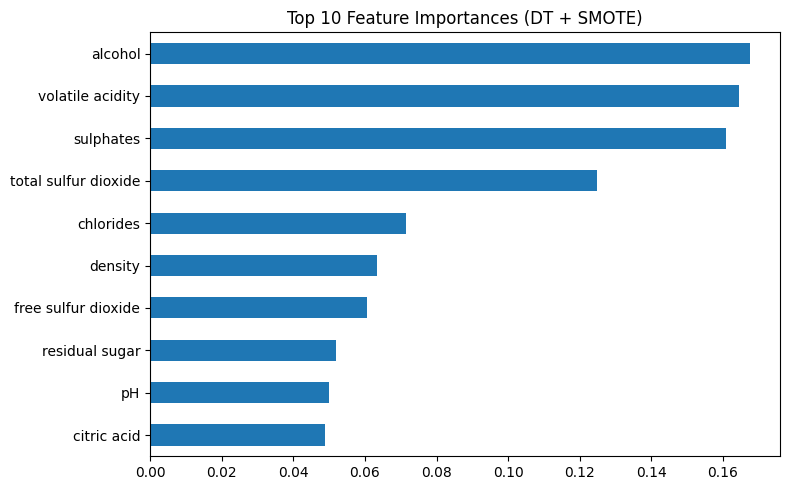

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_bal = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt_bal.fit(X_train, y_train)
y_pred_bal = dt_bal.predict(X_test)

print("\nDecision Tree (Class Weight Balanced):")
print(classification_report(y_test, y_pred_bal, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title("Tuned Decision Tree + SMOTE — Wine Quality (Test Set)")
plt.tight_layout()
plt.show()

# 6) (Optional) Inspect feature importances from the tuned tree
import pandas as pd
fi = pd.Series(best.named_steps['dt'].feature_importances_, index=X.columns)\
       .sort_values(ascending=False)
print("\nTop Feature Importances:\n", fi.head(10))

plt.figure(figsize=(8,5))
fi.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (DT + SMOTE)")
plt.tight_layout()
plt.show()

### Where SMOTE really shines

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 


=== Summary (Test Set) ===
                            Accuracy  Macro Precision  Macro Recall  Macro F1
Setting                                                                      
Baseline (No SMOTE)           0.5950           0.3011        0.2700    0.2723
SMOTE + LogisticRegression    0.4075           0.2700        0.2966    0.2525

--- Baseline (No SMOTE) — Classification Report ---
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         2
           4      0.000     0.000     0.000        13
           5      0.649     0.741     0.692       170
           6      0.538     0.619     0.576       160
           7      0.619     0.260     0.366        50
           8      0.000     0.000     0.000         5

    accuracy                          0.595       400
   macro avg      0.301     0.270     0.272       400
weighted avg      0.569     0.595     0.570       400


--- SMOTE + LogisticRegression — Classification Report ---
    

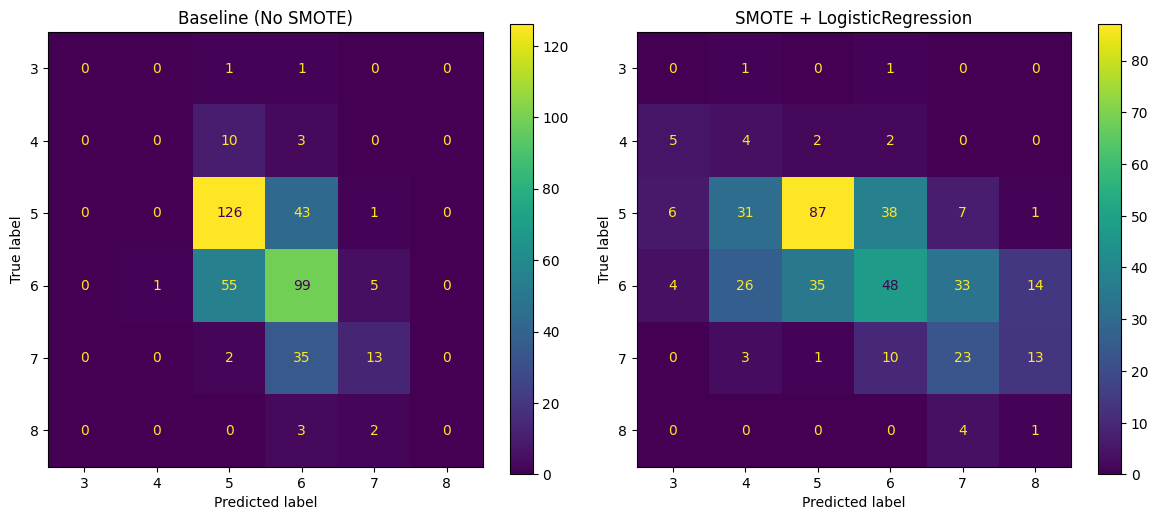


Train distribution AFTER SMOTE: Counter({5: 511, 6: 511, 7: 511, 4: 511, 3: 511, 8: 511})


In [15]:
# Logistic Regression on Wine Quality (multi-class) — With & Without SMOTE
# - Uses leakage-safe imblearn Pipelines so SMOTE happens ONLY on training folds
# - Prints a side-by-side metrics table (accuracy, macro-precision/recall/F1)
# - Also shows per-class reports and confusion matrices

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, accuracy_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1) Load data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

X = df.drop(columns=['quality'])
y = df['quality']  # multiclass labels (typically 3..8)

# 2) Train/Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Pipelines
baseline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=2000,
        n_jobs=-1,
        random_state=42
    ))
])

with_smote = ImbPipeline(steps=[
    # IMPORTANT: scale BEFORE SMOTE so k-NN in SMOTE works in normalized space
    ('scaler', StandardScaler()),
    ('smote', SMOTE(k_neighbors=5, random_state=42)),  # you can try 3 for very rare classes
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=2000,
        n_jobs=-1,
        random_state=42
    ))
])

# 4) Fit & predict
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

with_smote.fit(X_train, y_train)
y_pred_smote = with_smote.predict(X_test)

# 5) Helper to extract macro metrics
from sklearn.metrics import precision_recall_fscore_support

def macro_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1

acc_b, p_b, r_b, f1_b = macro_metrics(y_test, y_pred_base)
acc_s, p_s, r_s, f1_s = macro_metrics(y_test, y_pred_smote)

summary = pd.DataFrame({
    'Setting': ['Baseline (No SMOTE)', 'SMOTE + LogisticRegression'],
    'Accuracy': [acc_b, acc_s],
    'Macro Precision': [p_b, p_s],
    'Macro Recall': [r_b, r_s],
    'Macro F1': [f1_b, f1_s],
}).set_index('Setting')

print("\n=== Summary (Test Set) ===")
print(summary.round(4))

# 6) Detailed per-class reports
print("\n--- Baseline (No SMOTE) — Classification Report ---")
print(classification_report(y_test, y_pred_base, digits=3))

print("\n--- SMOTE + LogisticRegression — Classification Report ---")
print(classification_report(y_test, y_pred_smote, digits=3))

# 7) Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, ax=axes[0])
axes[0].set_title("Baseline (No SMOTE)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, ax=axes[1])
axes[1].set_title("SMOTE + LogisticRegression")
plt.tight_layout()
plt.show()

# 8) (Optional) Peek at how SMOTE balances training classes
#    (This inspects the fitted sampler on the training split)
smote_step = with_smote.named_steps['smote']
# Resample explicitly just to print counts
X_res, y_res = smote_step.fit_resample(
    with_smote.named_steps['scaler'].fit_transform(X_train), y_train
)
print("\nTrain distribution AFTER SMOTE:", Counter(y_res))

# Code Demo - Decision Tree Regressor

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: (20640, 8)
Baseline Decision Tree:
RMSE: 0.721
R² Score: 0.607

Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}

Tuned Decision Tree:
RMSE: 0.611
R² Score: 0.718


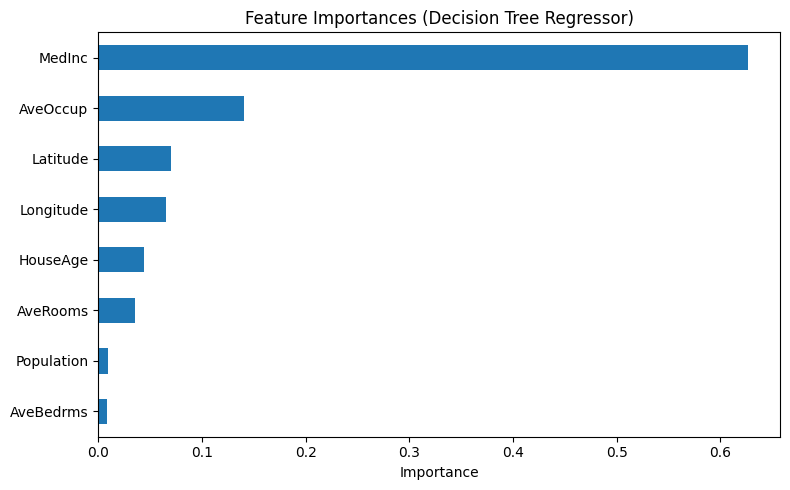

In [16]:
# Decision Tree Regressor on California Housing dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1) Load dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print("Feature names:", list(X.columns))
print("Shape:", X.shape)

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 3) Baseline Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# 4) Evaluate
y_pred = dt.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Baseline Decision Tree:")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# 5) Hyperparameter tuning
param_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "criterion": ["squared_error", "friedman_mse"]
}
grid = GridSearchCV(dt, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

best_dt = grid.best_estimator_
y_pred_best = best_dt.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f"\nTuned Decision Tree:")
print(f"RMSE: {rmse_best:.3f}")
print(f"R² Score: {r2_best:.3f}")

# 6) Feature Importances
importances = best_dt.feature_importances_
features = X.columns

fi = pd.Series(importances, index=features).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
fi.plot(kind='barh')
plt.title("Feature Importances (Decision Tree Regressor)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()